In [2]:
from google.colab import drive
drive.mount('/content/Mydrive')

Mounted at /content/Mydrive


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

os.chdir('/content/Mydrive/MyDrive')

In [56]:
batch_size = 32
img_height = 256
img_width = 256

In [134]:
data_dir='/content/Mydrive/MyDrive/proje/train'

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 52096 files belonging to 39 classes.
Using 36468 files for training.


In [135]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 52096 files belonging to 39 classes.
Using 15628 files for validation.


In [136]:
class_names = train_ds.class_names
print(class_names)


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl

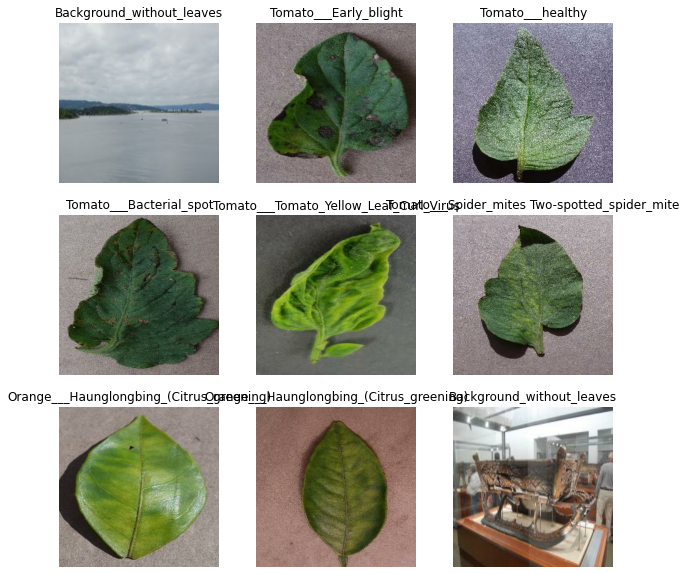

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [138]:
num_classes=39

In [139]:
model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(num_classes)
])

In [140]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [141]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 conv2d_21 (Conv2D)          (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 128, 128, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_22 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_23 (Conv2D)          (None, 64, 64, 64)       

In [147]:
epochs=50
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/50
1140/1140 [==============================] - 59s 52ms/step - loss: 0.0582 - accuracy: 0.9828 - val_loss: 0.3195 - val_accuracy: 0.9376
Epoch 2/50
1140/1140 [==============================] - 59s 51ms/step - loss: 0.0662 - accuracy: 0.9808 - val_loss: 0.3118 - val_accuracy: 0.9397
Epoch 3/50
1140/1140 [==============================] - 59s 51ms/step - loss: 0.0701 - accuracy: 0.9802 - val_loss: 0.3115 - val_accuracy: 0.9373
Epoch 4/50
1140/1140 [==============================] - 59s 51ms/step - loss: 0.0672 - accuracy: 0.9814 - val_loss: 0.2682 - val_accuracy: 0.9456
Epoch 5/50
1140/1140 [==============================] - 58s 51ms/step - loss: 0.0545 - accuracy: 0.9855 - val_loss: 0.3239 - val_accuracy: 0.9412
Epoch 6/50
1140/1140 [==============================] - 59s 51ms/step - loss: 0.0531 - accuracy: 0.9852 - val_loss: 0.4106 - val_accuracy: 0.9186
Epoch 7/50
1140/1140 [==============================] - 59s 51ms/step - loss: 0.0748 - accuracy: 0.9796 - val_loss: 0.2971 -

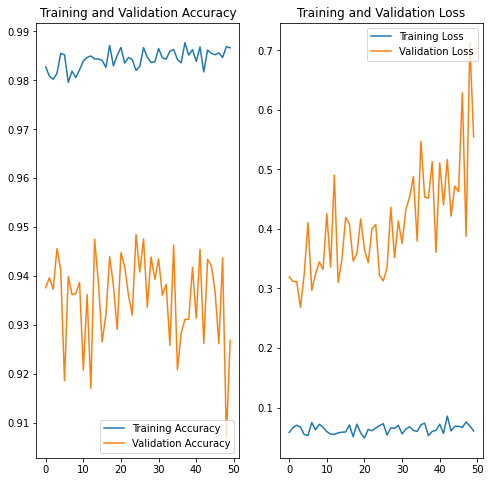

In [148]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [127]:
model.save('/content/Mydrive/MyDrive/proje/2/model.h5')

In [149]:
test_path = '/content/Mydrive/MyDrive/proje/Test/Tomato___Septoria_leaf_spot/image (26).JPG'

img = tf.keras.utils.load_img(
    test_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image belongs to {} with a {:.2f} Accuracy."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

This image belongs to Tomato___Septoria_leaf_spot with a 100.00 Accuracy.


In [150]:
data_dirrr='/content/Mydrive/MyDrive/proje/Test'

test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dirrr,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3352 files belonging to 39 classes.


In [151]:
model.evaluate(test_ds)

105/105 [==============================] - 6s 53ms/step - loss: 0.6504 - accuracy: 0.9200


[0.6504312753677368, 0.9200477600097656]